# Análisis Estacional Estratificado
## Clase vs vacaciones DENTRO de cada temporada del año

Para interpretar con seguridad hay que comparar regímenes escolares dentro de la
misma temporada del año (y escuela entre temporadas distintas), en lugar de comparar
"clases contra vacaciones" a secas.

Lógica: si la diferencia global clase-vacaciones fuera efecto de la escuela, debería
aparecer también al comparar dentro de una misma temporada (mismo clima). Si es efecto
de la temporada, la diferencia global se desploma al hacer la comparación justa.

**Data access / Acceso a los datos.** The SIMA measurements used here are not
redistributed in this repository (SIMA provided them for this study on the condition
that they are not disseminated); the repository holds the code, the official school
calendar and all derived results. This notebook reads files that notebooks 00 and 01
build from those measurements, and its configuration cell stops with a clear message
if they are missing. To rebuild them, request the annual workbooks from SIMA, place
them in `data_raw/` and run notebook 00 (its header gives the exact file format). /
Las mediciones de SIMA no se redistribuyen en este repositorio (SIMA las entregó para
este estudio con la condición de no difundirlas); el repositorio contiene el código, el
calendario oficial y todos los resultados derivados. Este notebook lee archivos que los
notebooks 00 y 01 construyen a partir de esas mediciones, y su celda de configuración
se detiene con un mensaje claro si faltan. Para reconstruirlos, solicite los libros
anuales a SIMA, colóquelos en `data_raw/` y corra el notebook 00 (su encabezado da el
formato exacto).

**Role in the analysis / Papel en el análisis.** Diagnostic and sensitivity: season-stratified contrasts with month fixed effects. / Diagnóstico y sensibilidad: contrastes estratificados por temporada con efectos fijos de mes. The analytical hierarchy of the whole repository is stated in the README. / La jerarquía analítica de todo el repositorio está en el README.

## 1. Configuración inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

contaminantes = ['CO', 'NO2', 'O3', 'PM10', 'PM2.5']
colores_contaminantes = {'CO': '#3498db', 'NO2': '#e74c3c', 'O3': '#2ecc71',
                         'PM10': '#f39c12', 'PM2.5': '#9b59b6'}
orden_temporadas = ['invierno', 'primavera', 'verano', 'otono']
etiquetas_temporada = {'invierno': 'Invierno (DEF)', 'primavera': 'Primavera (MAM)',
                       'verano': 'Verano (JJA)', 'otono': 'Otoño (SON)'}

output_dir = Path('../data_processed')
estacional_dir = output_dir / 'analisis_estacional'
estacional_dir.mkdir(exist_ok=True)

print("Librerías importadas exitosamente")

# Verificación de los datos de entrada (no se redistribuyen; ver la nota del encabezado)
# / Input data check (not redistributed; see the note in the header)
archivos_requeridos = [output_dir / 'panel_pico_hibrido.csv',
                       output_dir / 'panel_pico_MIMA.csv',
                       output_dir / 'gaps_franjas_hibrido.csv']
faltantes = [str(a) for a in archivos_requeridos if not a.exists()]
if faltantes:
    raise FileNotFoundError(
        "Faltan archivos derivados de las mediciones de SIMA, que no se redistribuyen en este repositorio. "
        "Solicite los libros anuales a SIMA, colóquelos en data_raw/ y corra los notebooks 00 y 01. / "
        "Files derived from the SIMA measurements are missing; they are not redistributed in this repository. "
        "Request the annual workbooks from SIMA, place them in data_raw/ and run notebooks 00 and 01. "
        f"Faltantes / missing: {faltantes}")
print(f"Datos de entrada encontrados / input data found: {len(archivos_requeridos)} archivos")

Librerías importadas exitosamente
Datos de entrada encontrados / input data found: 3 archivos


## 2. Carga de los paneles (notebook 01)

In [2]:
panel = pd.read_csv('../data_processed/panel_pico_hibrido.csv', parse_dates=['date'])
panel_mima = pd.read_csv('../data_processed/panel_pico_MIMA.csv', parse_dates=['date'])
gaps = pd.read_csv('../data_processed/gaps_franjas_hibrido.csv', parse_dates=['date'])

print("=" * 70)
print("PANELES CARGADOS")
print("=" * 70)
print(f"Panel franja pico (híbrido): {panel.shape[0]:,} filas día-estación")
print(f"Panel franja pico (MIMA):    {panel_mima.shape[0]:,} filas")
print(f"Panel de gaps entre franjas: {gaps.shape[0]:,} filas")
print(f"\nDías por temporada × régimen:")
print(panel.groupby(['temporada4', 'clase'])['date'].nunique().unstack())

PANELES CARGADOS
Panel franja pico (híbrido): 6,576 filas día-estación
Panel franja pico (MIMA):    6,576 filas
Panel de gaps entre franjas: 6,576 filas

Días por temporada × régimen:
clase           0      1
temporada4              
invierno     58.0  213.0
otono         NaN  273.0
primavera    36.0  240.0
verano      118.0  158.0


## 3. Función de contraste con errores agrupados por semana

Mismo estimador que el resto del análisis: OLS en logaritmo con efectos fijos de
estación de monitoreo, MES y día de la semana, errores agrupados por semana ISO
(misma corrección de grados de libertad que el pipeline de métodos). Dentro de un
estrato, los efectos fijos de mes hacen la comparación justa incluso cuando los días
de clase se concentran en una orilla de la temporada (p. ej. en verano, solo agosto).

### La ecuación del contraste

Dentro de cada estrato se estima, sobre $y$ = logaritmo del nivel (o el gap):

$$ y_{st} = \alpha + \beta\,\text{clase}_t + \eta_s + \gamma_{m(t)} + \delta_{d(t)} + \varepsilon_{st} $$

($\eta_s$: efecto fijo de estación de monitoreo; $\gamma_{m(t)}$: mes; $\delta_{d(t)}$:
día de la semana). Como $y$ está en logaritmo, el efecto se reporta en porcentaje:

$$ \%\Delta = (e^{\beta}-1)\times 100, \qquad \text{IC 95\%: } (e^{\beta \pm 1.96\,SE}-1)\times 100 $$

— por eso lo llamamos "IC 95% de $\beta$ transformado a %": el intervalo se construye
sobre $\beta$ (donde es simétrico y válido) y solo al final se convierte a porcentaje.
Los errores estándar se agrupan por semana ISO: los días de una misma semana se
parecen entre sí (meteorología persistente) y tratarlos como independientes daría
errores demasiado chicos. La fórmula del estimador agrupado está en el notebook 05.

In [3]:
def contraste_clase(df, columna_y, con_controles=True):
    """
    Estima el efecto de 'clase' sobre columna_y con errores agrupados por semana.
    Devuelve beta, %, IC 95%, p y tamaños de muestra.
    """
    df = df.dropna(subset=[columna_y]).copy()
    piezas = [pd.Series(1.0, index=df.index, name='const'), df['clase'].astype(float)]
    if con_controles:
        piezas.append(pd.get_dummies(df['estacion'], prefix='est', drop_first=True).astype(float))
        piezas.append(pd.get_dummies(df['mes'], prefix='mes', drop_first=True).astype(float))
        piezas.append(pd.get_dummies(df['dow'], prefix='dow', drop_first=True).astype(float))
    X = pd.concat(piezas, axis=1)
    Xv = X.values
    n, k = Xv.shape
    if n <= k or df['clase'].nunique() < 2:
        return None
    XtX_inv = np.linalg.inv(Xv.T @ Xv)
    y = df[columna_y].values
    beta_todos = XtX_inv @ Xv.T @ y
    residuos = y - Xv @ beta_todos

    grupos = pd.factorize(df['wk'])[0]
    orden = np.argsort(grupos, kind='stable')
    Xo, ro, go = Xv[orden], residuos[orden], grupos[orden]
    inicios = np.flatnonzero(np.r_[True, go[1:] != go[:-1]])
    G = len(inicios)
    S = np.zeros((k, k))
    fines = np.r_[inicios[1:], len(go)]
    for s, e in zip(inicios, fines):
        zg = Xo[s:e].T @ ro[s:e]
        S += np.outer(zg, zg)
    V = XtX_inv @ S @ XtX_inv
    V *= (G / (G - 1)) * ((n - 1) / (n - k))

    idx_clase = X.columns.get_loc('clase')
    beta = beta_todos[idx_clase]
    se = np.sqrt(V[idx_clase, idx_clase])
    z = beta / se
    return {'beta': beta, 'se': se,
            'pct': (np.exp(beta) - 1) * 100,
            'ci_lo_pct': (np.exp(beta - 1.96 * se) - 1) * 100,
            'ci_hi_pct': (np.exp(beta + 1.96 * se) - 1) * 100,
            'p': 2 * (1 - stats.norm.cdf(abs(z))),
            'n': n, 'G_semanas': G,
            'n_clase': int((df['clase'] == 1).sum()), 'n_vac': int((df['clase'] == 0).sum())}

print("Función de contraste lista")

Función de contraste lista


## 4. El patrón estacional: nivel mensual por régimen

Cada contaminante recorre su patrón anual. Las dos líneas (clases y vacaciones)
siguen el mismo patrón estacional: donde coexisten, casi se encima una con otra.

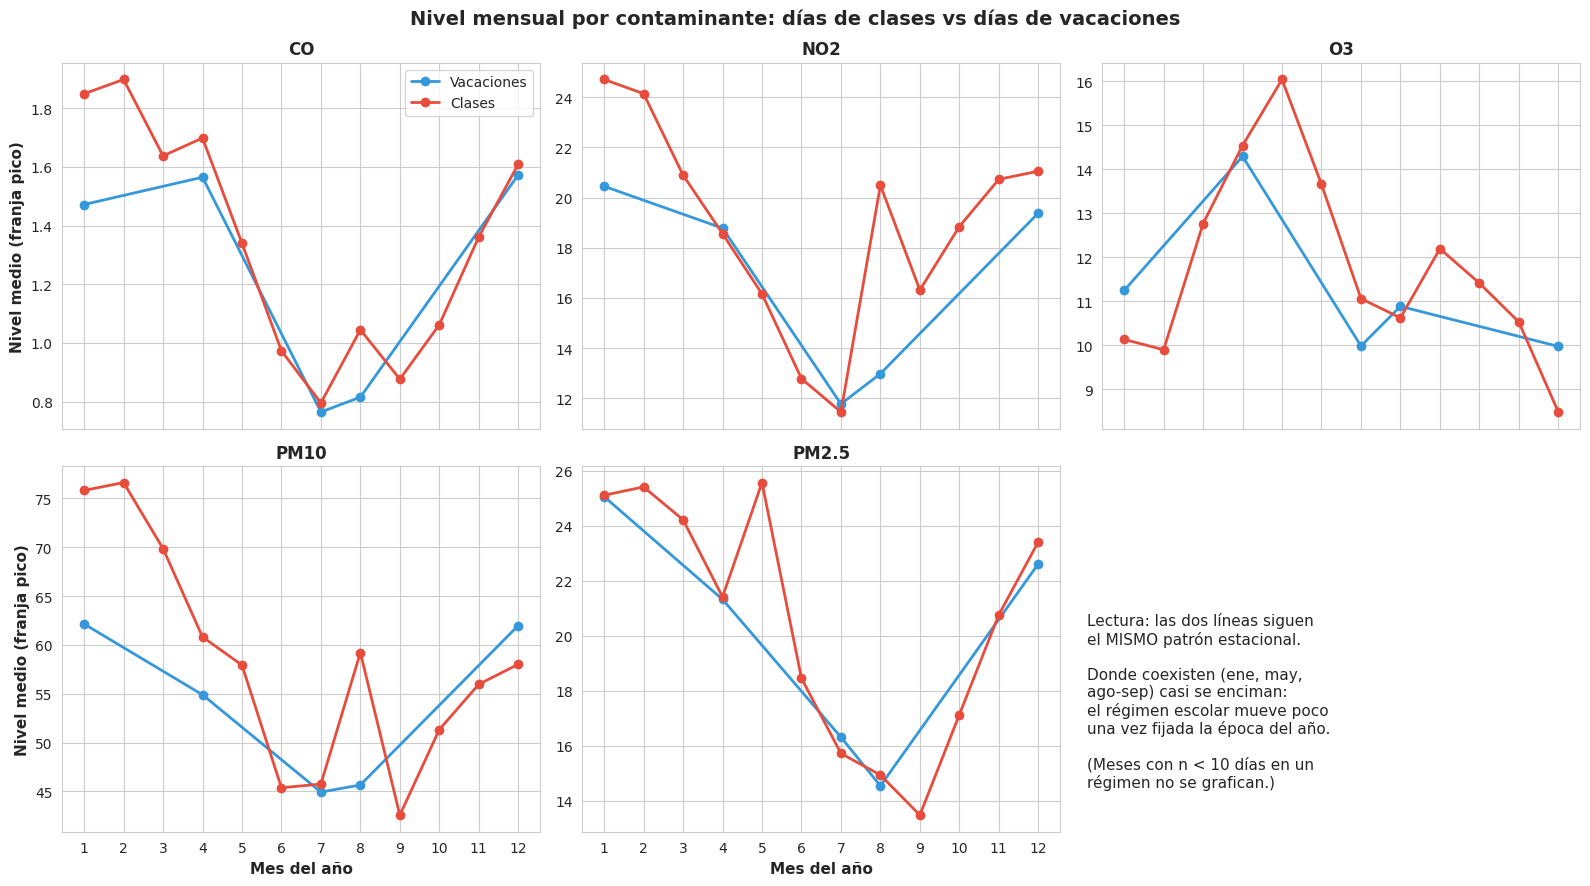

Guardado en: ../data_processed/analisis_estacional/nivel_mensual_por_regimen.csv
Guardado en: ../data_processed/analisis_estacional/n_dias_mensual_por_regimen.csv
Guardado gráfico en: ../data_processed/analisis_estacional/01_patron_mensual_por_regimen.png


In [4]:
nivel_mensual = (panel.groupby(['mes', 'clase'])[contaminantes].mean().reset_index())
conteo_mensual = panel.groupby(['mes', 'clase'])['date'].nunique().rename('n_dias').reset_index()
nivel_mensual = nivel_mensual.merge(conteo_mensual, on=['mes', 'clase'])
# Los puntos con menos de 10 días (p. ej. los 1-2 días de clase de diciembre) son ruido: fuera de la gráfica
nivel_mensual_grafica = nivel_mensual[nivel_mensual['n_dias'] >= 10]

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True)
axes = axes.flatten()

for i, c in enumerate(contaminantes):
    ax = axes[i]
    for cl, color, etiqueta in [(0, '#3498db', 'Vacaciones'), (1, '#e74c3c', 'Clases')]:
        sub = nivel_mensual_grafica[nivel_mensual_grafica['clase'] == cl]
        ax.plot(sub['mes'], sub[c], marker='o', color=color, label=etiqueta, linewidth=2)
    ax.set_title(c, fontsize=12, fontweight='bold')
    ax.set_xticks(range(1, 13))
    if i >= 3:
        ax.set_xlabel('Mes del año', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Nivel medio (franja pico)', fontsize=11, fontweight='bold')
axes[3].set_ylabel('Nivel medio (franja pico)', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=10)
axes[5].axis('off')
axes[5].text(0.05, 0.6, 'Lectura: las dos líneas siguen\nel MISMO patrón estacional.\n\nDonde coexisten (ene, may,\nago-sep) casi se enciman:\nel régimen escolar mueve poco\nuna vez fijada la época del año.\n\n(Meses con n < 10 días en un\nrégimen no se grafican.)',
             fontsize=11, va='top')
fig.suptitle('Nivel mensual por contaminante: días de clases vs días de vacaciones',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(estacional_dir / '01_patron_mensual_por_regimen.png', dpi=150, bbox_inches='tight')
plt.show()

nivel_mensual.to_csv(estacional_dir / 'nivel_mensual_por_regimen.csv', index=False)
conteo_mensual.to_csv(estacional_dir / 'n_dias_mensual_por_regimen.csv', index=False)
print(f"Guardado en: {estacional_dir / 'nivel_mensual_por_regimen.csv'}")
print(f"Guardado en: {estacional_dir / 'n_dias_mensual_por_regimen.csv'}")
print(f"Guardado gráfico en: {estacional_dir / '01_patron_mensual_por_regimen.png'}")

## 5. Exploración: niveles por temporada y régimen (boxplots)

La comparación "todas las clases vs todas las vacaciones" mezcla temporadas.
Aquí se repite el mismo contraste (con controles de estación de monitoreo, mes y
día de semana, errores por semana) restringido a cada temporada del año.
Otoño no se estima: con el calendario oficial no tiene días de vacaciones.

Esta sección es DESCRIPTIVA. Por eso la gráfica usa boxplots de las distribuciones,
una herramienta exploratoria que no pretende sostener un argumento causal, en lugar
de barras con intervalos. La tabla de contrastes con
controles se conserva abajo porque alimenta las conclusiones, pero el argumento formal
(con IC y errores agrupados) vive en la sección 7 y en los notebooks 05 y 06.

In [5]:
resultados_estratos = []
for c in contaminantes:
    fila_global = contraste_clase(panel, f'l_{c}')
    fila_global.update({'contaminante': c, 'estrato': 'global'})
    resultados_estratos.append(fila_global)
    for temporada in orden_temporadas:
        sub = panel[panel['temporada4'] == temporada]
        resultado = contraste_clase(sub, f'l_{c}')
        if resultado is None:
            continue
        resultado.update({'contaminante': c, 'estrato': temporada})
        resultados_estratos.append(resultado)

tabla_estratos = pd.DataFrame(resultados_estratos)[
    ['contaminante', 'estrato', 'pct', 'ci_lo_pct', 'ci_hi_pct', 'p', 'n', 'n_clase', 'n_vac', 'G_semanas']]
for col in ['pct', 'ci_lo_pct', 'ci_hi_pct']:
    tabla_estratos[col] = tabla_estratos[col].round(2)
tabla_estratos['p'] = tabla_estratos['p'].round(4)

print("=" * 70)
print("CONTRASTE CLASE VS VACACIONES: GLOBAL Y POR TEMPORADA (con controles)")
print("=" * 70)
print(tabla_estratos.to_string(index=False))

tabla_estratos.to_csv(estacional_dir / 'contrastes_por_temporada.csv', index=False)
print(f"\nGuardado en: {estacional_dir / 'contrastes_por_temporada.csv'}")

CONTRASTE CLASE VS VACACIONES: GLOBAL Y POR TEMPORADA (con controles)
contaminante   estrato    pct  ci_lo_pct  ci_hi_pct      p    n  n_clase  n_vac  G_semanas
          CO    global   7.16      -4.56      20.33 0.2419 6576     5304   1272        158
          CO  invierno  10.35      -2.27      24.61 0.1119 1626     1278    348         43
          CO primavera  -0.01     -30.18      43.18 0.9995 1656     1440    216         42
          CO    verano   9.90      -0.37      21.23 0.0592 1656      948    708         42
         NO2    global   9.82       0.03      20.57 0.0492 6576     5304   1272        158
         NO2  invierno  15.00       1.57      30.21 0.0274 1626     1278    348         43
         NO2 primavera   2.81     -13.74      22.53 0.7571 1656     1440    216         42
         NO2    verano  10.66      -7.71      32.68 0.2743 1656      948    708         42
          O3    global  -7.71     -19.62       5.96 0.2550 6576     5304   1272        158
          O3  invier

In [6]:
# También el contraste crudo (sin ningún control) para dimensionar la caída
resultados_crudos = []
for c in contaminantes:
    fila = {'contaminante': c}
    global_crudo = contraste_clase(panel, f'l_{c}', con_controles=False)
    fila['global_crudo_pct'] = round(global_crudo['pct'], 1)
    for temporada in ['invierno', 'primavera', 'verano']:
        sub = panel[panel['temporada4'] == temporada]
        resultado = contraste_clase(sub, f'l_{c}', con_controles=False)
        fila[f'{temporada}_crudo_pct'] = round(resultado['pct'], 1) if resultado else np.nan
    resultados_crudos.append(fila)
tabla_crudos = pd.DataFrame(resultados_crudos)
print("\nCONTRASTE CRUDO (sin controles), global vs dentro de temporada:")
print(tabla_crudos.to_string(index=False))
tabla_crudos.to_csv(estacional_dir / 'contrastes_crudos_por_temporada.csv', index=False)
print(f"Guardado en: {estacional_dir / 'contrastes_crudos_por_temporada.csv'}")


CONTRASTE CRUDO (sin controles), global vs dentro de temporada:
contaminante  global_crudo_pct  invierno_crudo_pct  primavera_crudo_pct  verano_crudo_pct
          CO              16.1                15.4                -11.6               6.7
         NO2              17.8                19.2                 -5.1              -2.4
          O3               2.2                -9.7                 -6.8              19.4
        PM10               6.8                 9.9                 11.3              -2.4
       PM2.5              10.4                 4.8                 14.9               9.1
Guardado en: ../data_processed/analisis_estacional/contrastes_crudos_por_temporada.csv


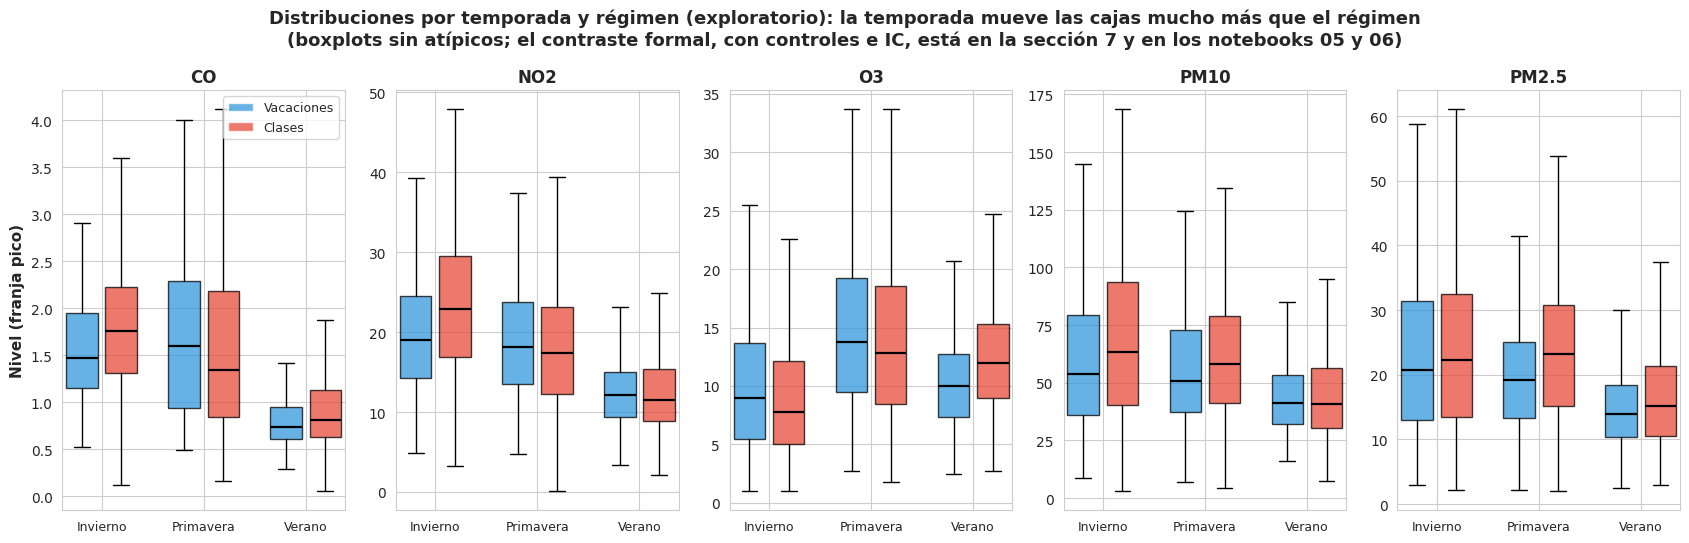

Guardado gráfico en: ../data_processed/analisis_estacional/02_boxplots_temporada_regimen.png


In [7]:
fig, axes = plt.subplots(1, 5, figsize=(17, 5.5), sharey=False)
orden_cajas = ['invierno', 'primavera', 'verano']
colores_regimen = {0: '#3498db', 1: '#e74c3c'}

for i, c in enumerate(contaminantes):
    ax = axes[i]
    posiciones, datos, colores_caja = [], [], []
    for j, temporada in enumerate(orden_cajas):
        for k, cl in enumerate((0, 1)):
            sub = panel[(panel['temporada4'] == temporada) & (panel['clase'] == cl)][c].dropna()
            if len(sub) == 0:
                continue
            datos.append(sub.values)
            posiciones.append(j * 2.6 + k)
            colores_caja.append(colores_regimen[cl])
    cajas = ax.boxplot(datos, positions=posiciones, widths=0.8, patch_artist=True,
                       showfliers=False, medianprops={'color': 'black', 'linewidth': 1.6})
    for caja, color in zip(cajas['boxes'], colores_caja):
        caja.set_facecolor(color)
        caja.set_alpha(0.75)
    ax.set_title(c, fontsize=12, fontweight='bold')
    ax.set_xticks([j * 2.6 + 0.5 for j in range(len(orden_cajas))])
    ax.set_xticklabels([etiquetas_temporada[tp].split(' ')[0] for tp in orden_cajas], fontsize=9)
    if i == 0:
        ax.set_ylabel('Nivel (franja pico)', fontsize=11, fontweight='bold')

leyenda = [plt.Rectangle((0, 0), 1, 1, fc='#3498db', alpha=0.75),
           plt.Rectangle((0, 0), 1, 1, fc='#e74c3c', alpha=0.75)]
axes[0].legend(leyenda, ['Vacaciones', 'Clases'], fontsize=9, loc='upper right')
fig.suptitle('Distribuciones por temporada y régimen (exploratorio): la temporada mueve las cajas mucho más que el régimen\n(boxplots sin atípicos; el contraste formal, con controles e IC, está en la sección 7 y en los notebooks 05 y 06)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(estacional_dir / '02_boxplots_temporada_regimen.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado gráfico en: {estacional_dir / '02_boxplots_temporada_regimen.png'}")

## 6. Espejo del argumento: régimen fijo, temporada variable

Si en lugar de fijar la temporada se fija el régimen (solo días de CLASE),
¿cuánto se mueven los niveles entre temporadas? Si la temporada mueve más que
el régimen, el confusor dominante queda identificado.

In [8]:
solo_clase = panel[panel['clase'] == 1]
solo_vacaciones = panel[panel['clase'] == 0]

niveles_temporada_clase = solo_clase.groupby('temporada4')[contaminantes].mean().reindex(orden_temporadas)
niveles_temporada_vac = solo_vacaciones.groupby('temporada4')[contaminantes].mean().reindex(orden_temporadas)

comparativo = []
for c in contaminantes:
    niveles = niveles_temporada_clase[c].dropna()
    rango_estacional_pct = (niveles.max() / niveles.min() - 1) * 100
    contraste_invierno = tabla_estratos.query("contaminante == @c and estrato == 'invierno'")['pct']
    comparativo.append({'contaminante': c,
                        'rango_entre_temporadas_solo_clase_pct': round(rango_estacional_pct, 1),
                        'clase_vs_vac_dentro_invierno_pct': round(float(contraste_invierno.iloc[0]), 1)})
tabla_comparativo = pd.DataFrame(comparativo)

print("=" * 70)
print("¿QUÉ MUEVE MÁS LOS NIVELES: LA TEMPORADA O EL RÉGIMEN ESCOLAR?")
print("=" * 70)
print(tabla_comparativo.to_string(index=False))
print("\n=> Con el régimen FIJO (solo clases), cambiar de temporada mueve los niveles varias")
print("   veces más que cambiar de régimen dentro de la misma temporada.")

tabla_comparativo.to_csv(estacional_dir / 'rango_temporadas_vs_regimen.csv', index=False)
niveles_temporada_clase.round(2).to_csv(estacional_dir / 'niveles_por_temporada_solo_clase.csv')
niveles_temporada_vac.round(2).to_csv(estacional_dir / 'niveles_por_temporada_solo_vacaciones.csv')
print(f"\nGuardado en: {estacional_dir / 'rango_temporadas_vs_regimen.csv'}")

¿QUÉ MUEVE MÁS LOS NIVELES: LA TEMPORADA O EL RÉGIMEN ESCOLAR?
contaminante  rango_entre_temporadas_solo_clase_pct  clase_vs_vac_dentro_invierno_pct
          CO                                   98.0                              10.3
         NO2                                   84.0                              15.0
          O3                                   50.8                             -15.4
        PM10                                   54.0                              -1.1
       PM2.5                                   44.7                              -1.2

=> Con el régimen FIJO (solo clases), cambiar de temporada mueve los niveles varias
   veces más que cambiar de régimen dentro de la misma temporada.

Guardado en: ../data_processed/analisis_estacional/rango_temporadas_vs_regimen.csv


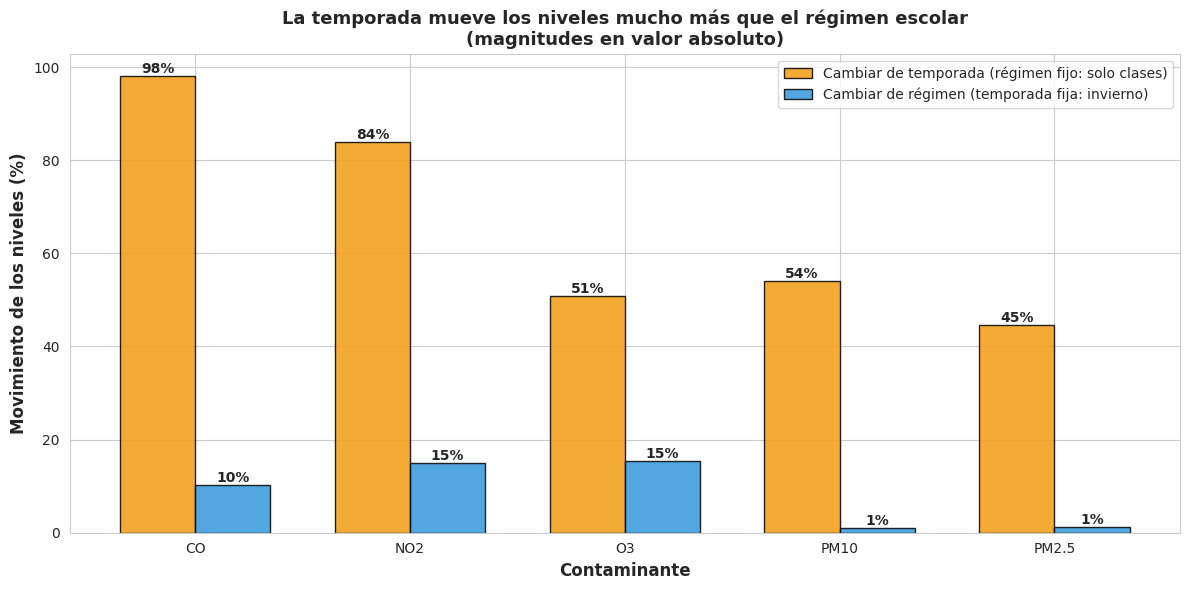

Guardado gráfico en: ../data_processed/analisis_estacional/03_temporada_vs_regimen.png


In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(contaminantes))
width = 0.35
bars1 = ax.bar(x - width/2, tabla_comparativo['rango_entre_temporadas_solo_clase_pct'], width,
               label='Cambiar de temporada (régimen fijo: solo clases)', color='#f39c12', alpha=0.85, edgecolor='black')
bars2 = ax.bar(x + width/2, tabla_comparativo['clase_vs_vac_dentro_invierno_pct'].abs(), width,
               label='Cambiar de régimen (temporada fija: invierno)', color='#3498db', alpha=0.85, edgecolor='black')

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{bar.get_height():.0f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(contaminantes)
ax.set_xlabel('Contaminante', fontsize=12, fontweight='bold')
ax.set_ylabel('Movimiento de los niveles (%)', fontsize=12, fontweight='bold')
ax.set_title('La temporada mueve los niveles mucho más que el régimen escolar\n(magnitudes en valor absoluto)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(estacional_dir / '03_temporada_vs_regimen.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado gráfico en: {estacional_dir / '03_temporada_vs_regimen.png'}")

## 7. El diseño de franjas, temporada por temporada

El gap pico-menos-fuera-de-pico del mismo día ya descuenta la temporada por construcción.
Si además se estima POR temporada, se ve en qué época del año vive la asociación y en
cuál no (y con cuánto soporte de días de vacaciones cuenta cada estrato).

Aquí los intervalos de confianza SÍ son el argumento
y por eso se reportan completos. Los gaps diarios son muy variables (la caja de un día
cualquiera es ancha), así que los estratos con menos soporte quedan con IC anchos: con
más datos — más ciclos escolares de SIMA — el error estándar se encoge como
$1/\sqrt{n}$ y varios de estos contrastes podrían resolverse. Repetir el análisis
agregando años es trabajo futuro natural. El diagnóstico de residuos del diseño
(Durbin-Watson) está en el notebook 05.

In [10]:
resultados_gap = []
for c in contaminantes:
    fila_global = contraste_clase(gaps, f'gap_{c}')
    fila_global.update({'contaminante': c, 'estrato': 'global'})
    resultados_gap.append(fila_global)
    for temporada in ['invierno', 'primavera', 'verano']:
        sub = gaps[gaps['temporada4'] == temporada]
        resultado = contraste_clase(sub, f'gap_{c}')
        if resultado is None:
            continue
        resultado.update({'contaminante': c, 'estrato': temporada})
        resultados_gap.append(resultado)

tabla_gap = pd.DataFrame(resultados_gap)[
    ['contaminante', 'estrato', 'pct', 'ci_lo_pct', 'ci_hi_pct', 'p', 'n']]
for col in ['pct', 'ci_lo_pct', 'ci_hi_pct']:
    tabla_gap[col] = tabla_gap[col].round(2)
tabla_gap['p'] = tabla_gap['p'].round(4)

print("=" * 70)
print("DOBLE DIFERENCIA DE FRANJAS, GLOBAL Y POR TEMPORADA")
print("=" * 70)
print(tabla_gap.to_string(index=False))

tabla_gap.to_csv(estacional_dir / 'gap_franjas_por_temporada.csv', index=False)
print(f"\nGuardado en: {estacional_dir / 'gap_franjas_por_temporada.csv'}")

DOBLE DIFERENCIA DE FRANJAS, GLOBAL Y POR TEMPORADA
contaminante   estrato    pct  ci_lo_pct  ci_hi_pct      p    n
          CO    global   4.56       1.49       7.71 0.0033 6576
          CO  invierno   2.48      -1.69       6.83 0.2484 1626
          CO primavera   7.20       1.62      13.09 0.0108 1656
          CO    verano   5.18      -1.26      12.05 0.1172 1656
         NO2    global   1.02      -6.15       8.74 0.7867 6576
         NO2  invierno  -1.61      -8.10       5.33 0.6403 1626
         NO2 primavera  -1.04     -14.61      14.68 0.8890 1656
         NO2    verano   6.55      -9.54      25.49 0.4476 1656
          O3    global  -2.61     -12.67       8.61 0.6347 6576
          O3  invierno   0.10     -19.12      23.88 0.9929 1626
          O3 primavera -11.07     -27.51       9.11 0.2609 1656
          O3    verano   1.53     -10.54      15.22 0.8140 1656
        PM10    global  -0.54      -5.68       4.89 0.8427 6576
        PM10  invierno  -3.28      -8.58       2.32 

## 8. Verificación con la imputación MIMA y por estación de monitoreo

In [11]:
# El estrato clave (invierno, el balanceado) repetido con el panel MIMA
print("=" * 70)
print("VERIFICACIÓN 1: EL ESTRATO DE INVIERNO CON LAS DOS IMPUTACIONES")
print("=" * 70)
panel_mima['temporada4'] = panel_mima['mes'].map({12: 'invierno', 1: 'invierno', 2: 'invierno',
                                                  3: 'primavera', 4: 'primavera', 5: 'primavera',
                                                  6: 'verano', 7: 'verano', 8: 'verano',
                                                  9: 'otono', 10: 'otono', 11: 'otono'})
for c in contaminantes:
    hibrido = contraste_clase(panel[panel['temporada4'] == 'invierno'], f'l_{c}')
    mima = contraste_clase(panel_mima[panel_mima['temporada4'] == 'invierno'], f'l_{c}')
    print(f"  {c}: híbrido {hibrido['pct']:+.1f}% (p={hibrido['p']:.3f}) | "
          f"MIMA {mima['pct']:+.1f}% (p={mima['p']:.3f})")

VERIFICACIÓN 1: EL ESTRATO DE INVIERNO CON LAS DOS IMPUTACIONES
  CO: híbrido +10.4% (p=0.112) | MIMA +9.2% (p=0.176)
  NO2: híbrido +15.0% (p=0.027) | MIMA +15.0% (p=0.028)
  O3: híbrido -15.4% (p=0.186) | MIMA -14.2% (p=0.212)


  PM10: híbrido -1.1% (p=0.932) | MIMA -0.9% (p=0.946)
  PM2.5: híbrido -1.2% (p=0.909) | MIMA -2.6% (p=0.814)


In [12]:
# ¿Alguna estación de monitoreo manda sola el contraste de invierno?
print("=" * 70)
print("VERIFICACIÓN 2: CONTRASTE DE INVIERNO POR ESTACIÓN DE MONITOREO (NO2, crudo)")
print("=" * 70)
invierno = panel[panel['temporada4'] == 'invierno']
por_estacion = []
for estacion_m, sub in invierno.groupby('estacion'):
    diferencia = (np.exp(sub[sub['clase'] == 1]['l_NO2'].mean() - sub[sub['clase'] == 0]['l_NO2'].mean()) - 1) * 100
    por_estacion.append({'estacion': estacion_m, 'dif_NO2_pct': round(diferencia, 1),
                        'n_clase': int((sub['clase'] == 1).sum()), 'n_vac': int((sub['clase'] == 0).sum())})
tabla_por_estacion = pd.DataFrame(por_estacion)
print(tabla_por_estacion.to_string(index=False))
tabla_por_estacion.to_csv(estacional_dir / 'invierno_NO2_por_estacion.csv', index=False)
print(f"\nGuardado en: {estacional_dir / 'invierno_NO2_por_estacion.csv'}")

VERIFICACIÓN 2: CONTRASTE DE INVIERNO POR ESTACIÓN DE MONITOREO (NO2, crudo)
 estacion  dif_NO2_pct  n_clase  n_vac
   CENTRO         19.0      213     58
 NORESTE3         15.3      213     58
NOROESTE3         16.3      213     58
   NORTE2         19.8      213     58
      SUR         24.4      213     58
SUROESTE2         20.6      213     58

Guardado en: ../data_processed/analisis_estacional/invierno_NO2_por_estacion.csv


## 9. Conclusiones del análisis estacional

In [13]:
no2_crudo_global = tabla_crudos.query("contaminante == 'NO2'").iloc[0]['global_crudo_pct']
no2_crudo_invierno = tabla_crudos.query("contaminante == 'NO2'").iloc[0]['invierno_crudo_pct']
no2_aj_invierno = tabla_estratos.query("contaminante == 'NO2' and estrato == 'invierno'").iloc[0]
co_aj_invierno = tabla_estratos.query("contaminante == 'CO' and estrato == 'invierno'").iloc[0]
gap_co_global = tabla_gap.query("contaminante == 'CO' and estrato == 'global'").iloc[0]
gap_co_invierno = tabla_gap.query("contaminante == 'CO' and estrato == 'invierno'").iloc[0]
gap_co_primavera = tabla_gap.query("contaminante == 'CO' and estrato == 'primavera'").iloc[0]

print("=" * 70)
print("CONCLUSIONES (con el calendario oficial SEP)")
print("=" * 70)
def _sig(p):
    return 'significativo' if p < 0.05 else 'ns'
if abs(no2_crudo_global) < 10:
    print(f"1. Con el calendario oficial el contraste crudo global no es dramático (NO2:")
    print(f"   {no2_crudo_global:+.0f}%): al contar junio y julio como lectivos, 'clases' no equivale a")
    print(f"   'meses fríos' y la mezcla de temporadas se equilibra sola en buena parte.")
else:
    print(f"1. El contraste crudo global sigue siendo grande (NO2: {no2_crudo_global:+.0f}%): la comparación")
    print(f"   cruda clases-vacaciones hereda la temporada (los bloques de vacaciones caen en meses")
    print(f"   atípicos), y por eso las comparaciones de este notebook se hacen DENTRO de cada temporada.")
print(f"2. Con régimen fijo (solo clases), cambiar de temporada mueve los niveles mucho más")
print(f"   que cambiar de régimen dentro de la misma temporada (ver tabla comparativa).")
print(f"3. Dentro de invierno (meses controlados) el nivel de CO con clases da")
print(f"   {co_aj_invierno['pct']:+.1f}% (p = {co_aj_invierno['p']:.3f}, {_sig(co_aj_invierno['p'])}); NO2 queda en {no2_aj_invierno['pct']:+.1f}%")
print(f"   ({_sig(no2_aj_invierno['p'])}). Ojo con la lectura: el CO de invierno junta TODO lo que se")
print(f"   reactiva en enero (trabajo + escuela), no solo la escuela.")
gap_co = tabla_gap[(tabla_gap['contaminante'] == 'CO') & (tabla_gap['estrato'] != 'global')].set_index('estrato')
estrato_max = gap_co['pct'].idxmax()
print(f"4. La parte específicamente MATUTINA es el gap de franjas: global {gap_co_global['pct']:+.1f}%")
print(f"   (p = {gap_co_global['p']:.4f}). Por temporada: " +
      "; ".join(f"{e} {gap_co.loc[e, 'pct']:+.1f}% ({_sig(gap_co.loc[e, 'p'])})" for e in gap_co.index) + ".")
print(f"   El estrato con la brecha más grande es {estrato_max}. En primavera las vacaciones del")
print(f"   estrato son Semana Santa, semanas que apagan el tráfico general, no solo el escolar,")
print(f"   así que la etiqueta 'clase' arrastra actividad de toda la ciudad.")
verano = tabla_estratos[tabla_estratos['estrato'] == 'verano']
n_sig_verano = int((verano['p'] < 0.05).sum()) if len(verano) else 0
print(f"5. Verano es el estrato informativo largo (junio-julio lectivos vs julio-agosto de")
print(f"   vacaciones): contaminantes con contraste clase-vacaciones significativo ahí: {n_sig_verano} de 5.")
print(f"6. Otoño no tiene días de vacaciones en el calendario oficial y no se estima.")
print(f"7. Las conclusiones se revisan con las dos imputaciones (híbrida y MIMA).")

print('\nFINALIZADO')

CONCLUSIONES (con el calendario oficial SEP)
1. El contraste crudo global sigue siendo grande (NO2: +18%): la comparación
   cruda clases-vacaciones hereda la temporada (los bloques de vacaciones caen en meses
   atípicos), y por eso las comparaciones de este notebook se hacen DENTRO de cada temporada.
2. Con régimen fijo (solo clases), cambiar de temporada mueve los niveles mucho más
   que cambiar de régimen dentro de la misma temporada (ver tabla comparativa).
3. Dentro de invierno (meses controlados) el nivel de CO con clases da
   +10.3% (p = 0.112, ns); NO2 queda en +15.0%
   (significativo). Ojo con la lectura: el CO de invierno junta TODO lo que se
   reactiva en enero (trabajo + escuela), no solo la escuela.
4. La parte específicamente MATUTINA es el gap de franjas: global +4.6%
   (p = 0.0033). Por temporada: invierno +2.5% (ns); primavera +7.2% (significativo); verano +5.2% (ns).
   El estrato con la brecha más grande es primavera. En primavera las vacaciones del
   estrato 